Dataset Loaded: (20, 6)

=== EFFICIENCY STATS ===
count    20.000000
mean      0.006801
std       0.000408
min       0.006072
25%       0.006519
50%       0.006803
75%       0.007020
max       0.007479
Name: efficiency, dtype: float64

Top Efficient Vendors:
                           vendor_name  efficiency
9    sahaja_samrudha_organic_producers    0.007479
2           bagalkot_onion_growers_fpc    0.007468
5                   malnad_nutri_foods    0.007411
19     mandya_organic_farmers_alliance    0.007228
8                        tapcms_hassan    0.007174
10       shimoga_agri_tech_cooperative    0.006969
17                   kolar_farmers_fpo    0.006910
16  dakshina_kannada_exporters_network    0.006888
13        chikkamagaluru_spice_traders    0.006884
7                     campco_mangaluru    0.006827

Least Efficient Vendors:
                          vendor_name  efficiency
11        phondaghat_pharmacy_&_honey    0.006072
15  kodagu_district_spice_cooperative    0.006227
1   

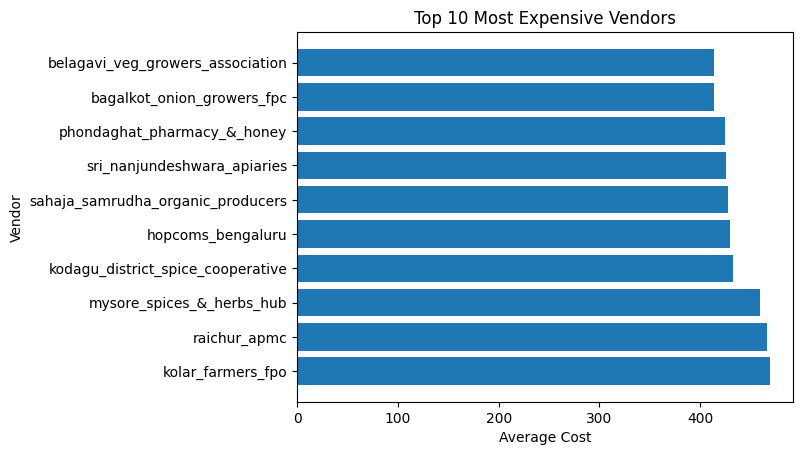

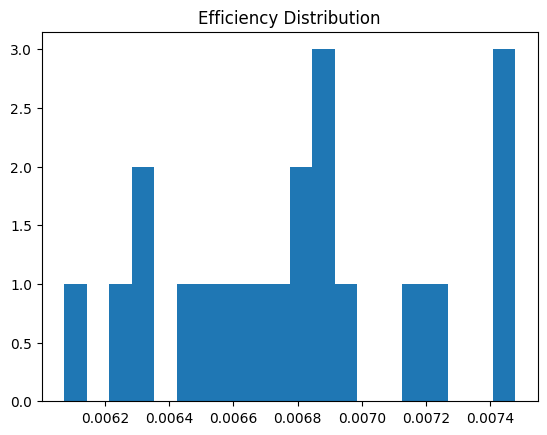


Cost Inefficient Vendors: 6

Day 14 Analysis Completed Successfully


In [1]:
# Day 14 - Vendor Cost Efficiency Analysis
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------------------------------------
# PATH SETUP
# ----------------------------------------------------------

PROJECT_ROOT = Path().resolve().parent

INPUT_FILE = PROJECT_ROOT / "03_processed_data/vendor_enriched.csv"

OUTPUT_DIR = PROJECT_ROOT / "03_processed_data"
VIS_DIR = PROJECT_ROOT / "04_visualizations"

OUTPUT_DIR.mkdir(exist_ok=True)
VIS_DIR.mkdir(exist_ok=True)

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------

df = pd.read_csv(INPUT_FILE)

print("Dataset Loaded:", df.shape)

# ----------------------------------------------------------
# 1. CREATE EFFICIENCY METRIC
# ----------------------------------------------------------

# Efficiency = quantity per unit cost
df["efficiency"] = df["total_quantity"] / (df["total_cost"] + 0.0001)

# ----------------------------------------------------------
# 2. BASIC STATISTICS
# ----------------------------------------------------------

print("\n=== EFFICIENCY STATS ===")
print(df["efficiency"].describe())

# ----------------------------------------------------------
# 3. TOP & BOTTOM VENDORS
# ----------------------------------------------------------

# Most Efficient Vendors
top_efficient = df.sort_values(
    by="efficiency",
    ascending=False
).head(10)

# Least Efficient Vendors
low_efficient = df.sort_values(
    by="efficiency"
).head(10)

print("\nTop Efficient Vendors:")
print(top_efficient[["vendor_name", "efficiency"]])

print("\nLeast Efficient Vendors:")
print(low_efficient[["vendor_name", "efficiency"]])

# SAVE
top_efficient.to_csv(
    OUTPUT_DIR / "top_efficient_vendors.csv",
    index=False
)

low_efficient.to_csv(
    OUTPUT_DIR / "low_efficient_vendors.csv",
    index=False
)

# ----------------------------------------------------------
# 4. COST RANKING
# ----------------------------------------------------------

# Top Expensive Vendors
top_expensive = df.sort_values(
    by="avg_cost",
    ascending=False
).head(10)

# Cheapest Vendors
cheapest = df.sort_values(
    by="avg_cost"
).head(10)

top_expensive.to_csv(
    OUTPUT_DIR / "top_expensive_vendors.csv",
    index=False
)

cheapest.to_csv(
    OUTPUT_DIR / "cheapest_vendors.csv",
    index=False
)

# ----------------------------------------------------------
# 5. VISUALIZATION - TOP EXPENSIVE
# ----------------------------------------------------------

plt.figure()

plt.barh(
    top_expensive["vendor_name"],
    top_expensive["avg_cost"]
)

plt.xlabel("Average Cost")
plt.ylabel("Vendor")
plt.title("Top 10 Most Expensive Vendors")
plt.savefig(VIS_DIR / "top_expensive_suppliers.png")
plt.show()
plt.close()

# ----------------------------------------------------------
# 6. VISUALIZATION - EFFICIENCY DISTRIBUTION
# ----------------------------------------------------------

plt.figure()

plt.hist(df["efficiency"], bins=20)

plt.title("Efficiency Distribution")

plt.savefig(VIS_DIR / "efficiency_distribution.png")
plt.show()
plt.close()

# ----------------------------------------------------------
# 7. COST INEFFICIENT VENDORS
# High cost + low efficiency
# ----------------------------------------------------------

avg_cost = df["avg_cost"].mean()
avg_eff = df["efficiency"].mean()

cost_inefficient = df[
    (df["avg_cost"] > avg_cost) &
    (df["efficiency"] < avg_eff)
]

print("\nCost Inefficient Vendors:", len(cost_inefficient))

cost_inefficient.to_csv(
    OUTPUT_DIR / "cost_inefficient_vendors.csv",
    index=False
)

# ----------------------------------------------------------
# 8. SAVE UPDATED DATASET
# ----------------------------------------------------------

df.to_csv(
    OUTPUT_DIR / "vendor_efficiency.csv",
    index=False
)

# ----------------------------------------------------------
# 9. FINAL STATUS
# ----------------------------------------------------------

print("\nDay 14 Analysis Completed Successfully")